# Compare Deepert vs pyGIMLi (Correctness Validation)

This notebook benchmarks Deepert and pyGIMLi on a **representative day** selected from:
`Day 1, 190, 294, 365` (from `examples/0_rain_et_day_selection.ipynb`).

Figures generated:
1. Single-time forward comparison (Deepert / pyGIMLi / residual), 1x3.
2. Taylor test for AD gradient + scatter comparison, 1x3.
3. First-iteration gradient comparison in time-lapse inversion (one target model), 1x3.
4. Inversion recovery comparison (recovered Deepert / recovered pyGIMLi / residual), 1x3.


In [22]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PolyCollection
from matplotlib.colors import LogNorm, TwoSlopeNorm
from scipy.spatial import cKDTree

ROOT = Path.cwd().resolve()
if not (ROOT / 'examples').exists() and (ROOT.parent / 'examples').exists():
    ROOT = ROOT.parent

EXAMPLES = ROOT / 'examples'
RESULT = ROOT / 'result'
MODEL_DIR = ROOT / 'parflow_models'
RES2D = ROOT / 'resistivity_models_2d'

# Representative days selected in 0_rain_et_day_selection.ipynb
REP_DAYS = [1, 190, 294, 365]
TARGET_DAY = 190
TARGET_STEP = int((TARGET_DAY - 1) * 24)
TARGET_MODEL = RES2D / f'resistivity2d_y2_t{TARGET_STEP:05d}.npy'

TL_DEE_DIR = RESULT / '2_timelapsedERT_inversion_deepert'
TL_PYG_DIR = RESULT / '2_timelapsedERT_inversion_pygimli'
TL_FWD_DIR = RESULT / '1_timelapsedERT_forward_deepert'
COMPARE_OUT_DIR = RESULT / '2_timelapsedERT_inversion_deepert'
COMPARE_OUT_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT        :', ROOT)
print('TARGET_DAY  :', TARGET_DAY)
print('TARGET_STEP :', TARGET_STEP)
print('TARGET_MODEL:', TARGET_MODEL)

ROOT        : /home/luffy/deepertv1
TARGET_DAY  : 190
TARGET_STEP : 4536
TARGET_MODEL: /home/luffy/deepertv1/resistivity_models_2d/resistivity2d_y2_t04536.npy


In [23]:
# Single-time forward data loading for the selected day
DEE_NPZ = RESULT / '1_single_forward_deepert' / 'synthetic_ert_terrain_vardz.npz'
PYG_NPZ = RESULT / '1_single_forward_pygimli' / 'synthetic_ert_terrain_vardz.npz'

print('Using Deepert forward npz:', DEE_NPZ)
print('Using pyGIMLi forward npz:', PYG_NPZ)

with np.load(DEE_NPZ) as d:
    dee = {k: np.asarray(d[k]) for k in d.files}
with np.load(PYG_NPZ) as d:
    pyg = {k: np.asarray(d[k]) for k in d.files}

print('DEE keys:', sorted(dee.keys()))
print('PYG keys:', sorted(pyg.keys()))

Using Deepert forward npz: /home/luffy/deepertv1/result/1_single_forward_deepert/synthetic_ert_terrain_vardz.npz
Using pyGIMLi forward npz: /home/luffy/deepertv1/result/1_single_forward_pygimli/synthetic_ert_terrain_vardz.npz
DEE keys: ['a', 'b', 'elec_x', 'elec_z', 'err', 'layer_thickness', 'm', 'n', 'rhoa', 'x_nodes', 'y_index', 'z_top']
PYG keys: ['a', 'b', 'elec_x', 'elec_z', 'err', 'layer_thickness', 'm', 'n', 'rhoa', 'x_nodes', 'y_index', 'z_top']


Saved: /home/luffy/deepertv1/result/2_timelapsedERT_inversion_deepert/1_compare_forward.png


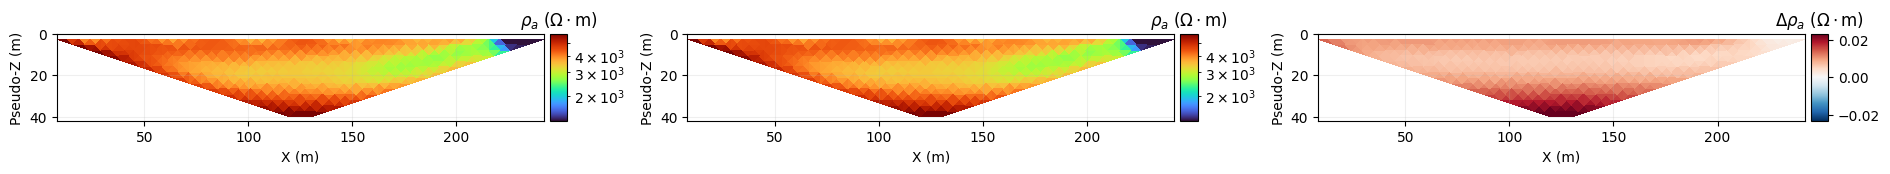

{'forward_rmse': 0.010253769173194694, 'forward_rel_l2': 2.6095592757866646e-06}


In [24]:
# 1) Single-time forward: deepert / pygimli / residual
import matplotlib.tri as mtri
from mpl_toolkits.axes_grid1 import make_axes_locatable

r_dee = np.asarray(dee['rhoa'], dtype=float).ravel()
r_pyg = np.asarray(pyg['rhoa'], dtype=float).ravel()
res = r_dee - r_pyg

rmse = float(np.sqrt(np.mean(res**2)))
rel = float(np.linalg.norm(res) / max(np.linalg.norm(r_dee), 1.0e-12))

abmn_dee = np.column_stack((dee['a'], dee['b'], dee['m'], dee['n'])).astype(np.int32)
abmn_pyg = np.column_stack((pyg['a'], pyg['b'], pyg['m'], pyg['n'])).astype(np.int32)

# Pseudosection coordinates
# X: center of (A,B,M,N); Z: pseudo-depth from array span
ex = np.asarray(dee['elec_x'], dtype=float).ravel()
a, b, m, n = abmn_dee.T
x_center = 0.25 * (ex[a] + ex[b] + ex[m] + ex[n])
z_pseudo = 0.25 * np.abs(ex[n] - ex[a])
if np.all(z_pseudo <= 0.0):
    dx = float(np.median(np.diff(np.sort(np.unique(ex)))))
    z_pseudo = 0.25 * np.abs(n - a) * dx

tri = mtri.Triangulation(x_center, z_pseudo)

rho_positive = np.concatenate([r_dee[r_dee > 0.0], r_pyg[r_pyg > 0.0]])
vmin = float(np.percentile(rho_positive, 2.0))
vmax = float(np.percentile(rho_positive, 98.0))
if vmax <= vmin:
    vmax = vmin * 1.01
norm_rho = LogNorm(vmin=vmin, vmax=vmax)

res_scale = float(np.percentile(np.abs(res), 98.0))
res_scale = max(res_scale, 1.0e-12)
norm_res = TwoSlopeNorm(vcenter=0.0, vmin=-res_scale, vmax=res_scale)


fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))

pc0 = axes[0].tripcolor(tri, r_dee, shading='flat', cmap='turbo', norm=norm_rho)
axes[0].set_aspect('equal', adjustable='box')

pc1 = axes[1].tripcolor(tri, r_pyg, shading='flat', cmap='turbo', norm=norm_rho)
axes[1].set_aspect('equal', adjustable='box')

pc2 = axes[2].tripcolor(tri, res, shading='flat', cmap='RdBu_r', norm=norm_res)
axes[2].set_aspect('equal', adjustable='box')
for ax in axes:
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Pseudo-Z (m)')
    ax.set_xlim(float(np.min(x_center)), float(np.max(x_center)))
    ax.set_ylim(float(np.max(z_pseudo) * 1.05), 0.0)
    ax.grid(alpha=0.2)

def _add_cbar_same_height(ax, mappable, title, *, size='3.5%', pad=0.06):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size=size, pad=pad)
    cb = fig.colorbar(mappable, cax=cax)
    cb.ax.set_title(title)
    return cb

_add_cbar_same_height(axes[0], pc0, r'$\rho_a$ ($\Omega\cdot$m)')
_add_cbar_same_height(axes[1], pc1, r'$\rho_a$ ($\Omega\cdot$m)')
_add_cbar_same_height(axes[2], pc2, r'$\Delta \rho_a$ ($\Omega\cdot$m)')

plt.tight_layout()
forward_fig = COMPARE_OUT_DIR / '1_compare_forward.png'
fig.savefig(forward_fig, dpi=600, bbox_inches='tight')
print('Saved:', forward_fig)
plt.show()

print({
    'forward_rmse': rmse,
    'forward_rel_l2': rel,
})


23/05/26 - 20:51:38 - pyGIMLi - INFO - Cache /home/luffy/deepertv1/.venv/lib/python3.11/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (0.0s x 46): /home/luffy/.cache/pygimli/6082443632689842628
23/05/26 - 20:51:38 - pyGIMLi - INFO - Found 2 regions.
23/05/26 - 20:51:38 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
23/05/26 - 20:51:38 - pyGIMLi - INFO - Creating forward mesh from region infos.
23/05/26 - 20:51:38 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
23/05/26 - 20:51:38 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 3015 Cells: 5728 Boundaries: 4446


Saved: /home/luffy/deepertv1/result/2_timelapsedERT_inversion_deepert/1_compare_gradient.png


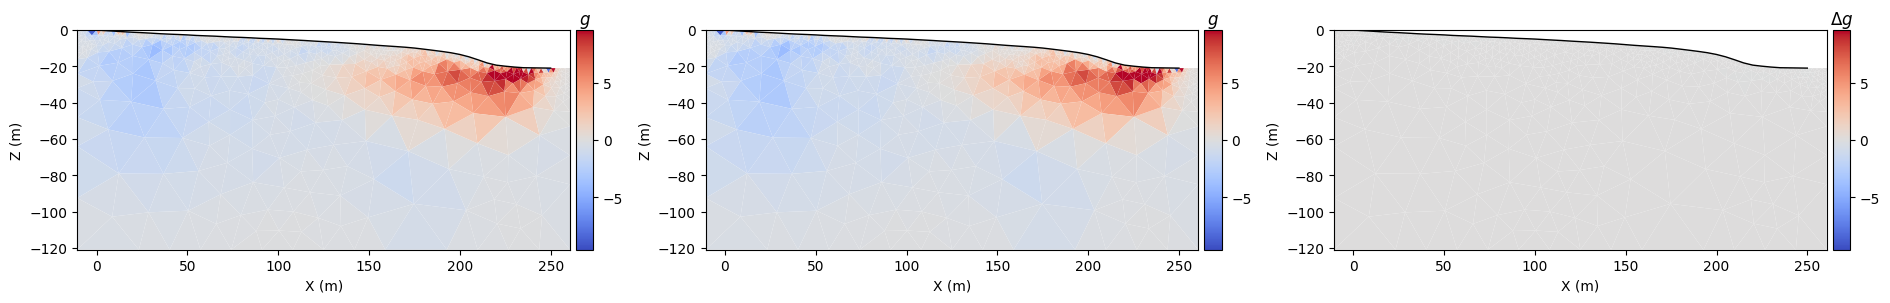

Gradient norms:
{'||g_dee||2': 81.61211099470873, '||g_pyg||2': 81.61181734858249, '||g_dee-g_pyg_interp||2': 0.0053703751035558515, 'rel_l2': 6.58036538707354e-05}


In [25]:
# 2) First-iteration gradient comparison in time-lapse inversion
from deepert.inversion import ParameterizedERTForward2p5D
from deepert.mesh import Mesh
from deepert.survey import Survey
from deepert.utils.torch_runtime import torch_runtime
import pygimli as pg
from pygimli.physics import ert
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Keep Deepert forward/Jacobian in float32 here to avoid mixed dtype (double vs float).
torch_runtime.config.update('torch_enable_float64', False)


def mesh_arrays_from_pygimli(pg_mesh):
    nodes = np.asarray([[float(n.x()), float(n.y())] for n in pg_mesh.nodes()], dtype=float)
    cells = []
    for cell in pg_mesh.cells():
        cell_ids = [int(cell.node(i).id()) for i in range(cell.nodeCount())]
        cells.append(np.asarray(cell_ids, dtype=np.int32))
    return nodes, cells


def cell_centers(nodes, cells):
    return np.asarray([nodes[cell].mean(axis=0) for cell in cells], dtype=float)


def plot_cell_scalar(ax, nodes, cells, values, *, cmap, norm):
    polys = [nodes[cell] for cell in cells]
    coll = PolyCollection(
        polys,
        array=np.asarray(values, dtype=float),
        cmap=cmap,
        norm=norm,
        edgecolors='none',
    )
    ax.add_collection(coll)
    ax.set_xlim(float(np.min(nodes[:, 0])), float(np.max(nodes[:, 0])))
    ax.set_ylim(float(np.min(nodes[:, 1])), float(np.max(nodes[:, 1])))
    ax.set_aspect('equal')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Z (m)')
    return coll


def _overlay_terrain(ax, terrain_x, terrain_z, *, color='k', lw=1.1):
    ax.plot(terrain_x, terrain_z, color=color, lw=lw, zorder=5)


# Load selected timestep forward observation (same for both inversions)
obs_npz = TL_FWD_DIR / f'synthetic_ert_terrain_vardz_t{TARGET_STEP:05d}.npz'
assert obs_npz.exists(), f'Missing {obs_npz}'
with np.load(obs_npz) as d:
    obs = {k: np.asarray(d[k]) for k in d.files}

obs_rhoa = np.asarray(obs['rhoa'], dtype=np.float32).ravel()
obs_log = np.log(obs_rhoa)
std = (
    np.log1p(np.asarray(obs['err'], dtype=np.float32).ravel())
    if 'err' in obs
    else np.full_like(obs_log, np.log1p(np.float32(0.05)))
)
weight = 1.0 / std

measurements = np.column_stack((obs['a'], obs['b'], obs['m'], obs['n'])).astype(np.int32)
electrodes = np.column_stack((obs['elec_x'], obs['elec_z'])).astype(float)
terrain_x = np.asarray(obs['x_nodes'], dtype=float).ravel()
terrain_z = np.asarray(obs['z_top'], dtype=float).ravel()

rho0 = float(np.median(obs_rhoa))

# Deepert gradient on Deepert inversion mesh
mesh_npz = TL_DEE_DIR / 'timelapse_inversion_mesh.npz'
with np.load(mesh_npz) as d:
    dee_mesh_data = {k: np.asarray(d[k]) for k in d.files}

dee_reg_mesh = Mesh.from_arrays(dee_mesh_data['nodes'], dee_mesh_data['cells'])
dee_fwd_mesh = Mesh.from_arrays(dee_mesh_data['forward_nodes'], dee_mesh_data['forward_cells'])
dee_param_ids = np.asarray(dee_mesh_data['parameter_cell_ids'], dtype=np.int32).ravel()
dee_survey = Survey.from_arrays(electrodes, measurements)

dee_forward = ParameterizedERTForward2p5D.from_mesh_survey(
    dee_fwd_mesh,
    dee_survey,
    dee_param_ids,
    regularization_mesh=dee_reg_mesh,
    linear_solver_backend='auto',
)
try:
    dee_log_model = np.log(
        np.full(dee_reg_mesh.cell_count, np.float32(rho0), dtype=np.float32)
    ).astype(np.float32)
    dee_pred_log, dee_J = dee_forward.forward_and_jacobian(dee_log_model, log_transform=True)
    dee_res = (dee_pred_log - obs_log) * weight
    grad_dee = dee_J.T @ dee_res
finally:
    dee_forward.close()

nodes_dee = np.asarray(dee_mesh_data['nodes'], dtype=float)
cells_dee = [
    np.asarray(cell, dtype=np.int32)
    for cell in np.asarray(dee_mesh_data['cells'], dtype=np.int32)
]
centers_dee = cell_centers(nodes_dee, cells_dee)

# pyGIMLi gradient on pyGIMLi inversion mesh
pyg_mesh_path = TL_PYG_DIR / 'timelapse_inversion_mesh.bms'
assert pyg_mesh_path.exists(), f'Missing {pyg_mesh_path}'
pyg_mesh = pg.load(str(pyg_mesh_path))

scheme_exact = ert.createData(elecs=electrodes, schemeName='wa')
wa_abmn = np.column_stack(
    (
        np.asarray(scheme_exact['a'], dtype=np.int32),
        np.asarray(scheme_exact['b'], dtype=np.int32),
        np.asarray(scheme_exact['m'], dtype=np.int32),
        np.asarray(scheme_exact['n'], dtype=np.int32),
    )
)
if not np.array_equal(wa_abmn, measurements):
    raise ValueError('ABMN order mismatch between forward data and pyGIMLi WA scheme.')

fop = ert.ERTModelling()
fop.setData(scheme_exact)
fop.setMesh(pyg_mesh)

# Use paraDomain to stay consistent with inversion parameter cells
n_param_pyg = int(np.asarray(np.load(TL_PYG_DIR / 'final_models.npy')).shape[0])
rho0_vec = np.full(n_param_pyg, rho0, dtype=float)
pyg_pred = np.asarray(fop.response(rho0_vec), dtype=float).ravel()
pyg_pred_log = np.log(pyg_pred)
fop.createJacobian(pg.Vector(rho0_vec))
J_raw = pg.utils.gmat2numpy(fop.jacobian())
rho_for_jac = np.full(J_raw.shape[1], rho0, dtype=float)
J_pyg_log = (J_raw * rho_for_jac[None, :]) / pyg_pred[:, None]
pyg_res = (pyg_pred_log - obs_log) * weight
grad_pyg = J_pyg_log.T @ pyg_res

pyg_para_mesh = fop.paraDomain
nodes_pyg, cells_pyg = mesh_arrays_from_pygimli(pyg_para_mesh)
centers_pyg = cell_centers(nodes_pyg, cells_pyg)

# Interpolate pyGIMLi gradient onto Deepert cells for residual view
nn = cKDTree(centers_pyg)
idx_nn = nn.query(centers_dee)[1]
grad_pyg_on_dee = grad_pyg[idx_nn]
grad_residual = grad_dee - grad_pyg_on_dee

scale = float(np.percentile(np.abs(np.concatenate([grad_dee, grad_pyg, grad_residual])), 99.0))
scale = max(scale, 1.0e-12)
norm_grad = TwoSlopeNorm(vcenter=0.0, vmin=-scale, vmax=scale)

fig, axes = plt.subplots(1, 3, figsize=(19.0, 4.6))

c0 = plot_cell_scalar(
    axes[0], nodes_dee, cells_dee, grad_dee,
    cmap='coolwarm', norm=norm_grad,
)

c1 = plot_cell_scalar(
    axes[1], nodes_pyg, cells_pyg, grad_pyg,
    cmap='coolwarm', norm=norm_grad,
)

c2 = plot_cell_scalar(
    axes[2], nodes_dee, cells_dee, grad_residual,
    cmap='coolwarm', norm=norm_grad,
)

for ax in axes:
    _overlay_terrain(ax, terrain_x, terrain_z, color='k', lw=1.0)


def _add_cbar_same_height(ax, mappable, title=r'$g$', *, size='3.5%', pad=0.06):
    if hasattr(mappable, 'mappable'):
        mappable = mappable.mappable
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size=size, pad=pad)
    cb = fig.colorbar(mappable, cax=cax)
    cb.ax.set_title(title, pad=4)
    return cb


_add_cbar_same_height(axes[0], c0, r'$g$')
_add_cbar_same_height(axes[1], c1, r'$g$')
_add_cbar_same_height(axes[2], c2, r'$\Delta g$')

plt.tight_layout()
gradient_fig = COMPARE_OUT_DIR / '1_compare_gradient.png'
fig.savefig(gradient_fig, dpi=600, bbox_inches='tight')
print('Saved:', gradient_fig)
plt.show()

print('Gradient norms:')
print({
    '||g_dee||2': float(np.linalg.norm(grad_dee)),
    '||g_pyg||2': float(np.linalg.norm(grad_pyg)),
    '||g_dee-g_pyg_interp||2': float(np.linalg.norm(grad_residual)),
    'rel_l2': float(np.linalg.norm(grad_residual) / max(np.linalg.norm(grad_dee), 1.0e-12)),
})


Saved: /home/luffy/deepertv1/result/2_timelapsedERT_inversion_deepert/1_compare_inversion.png


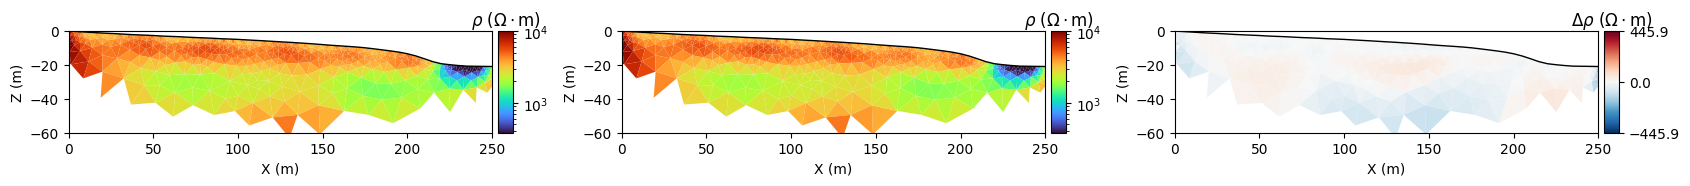

Recovery residual metrics (masked, on Deepert mesh):
{'n_valid_cells': 729, 'rmse': 71.17946567431649, 'mae': 24.782279157716367, 'rel_l2': 0.01632999395324785}


In [26]:
# 3) Inversion recovery comparison: Deepert / pyGIMLi / residual
steps_dee = np.asarray(np.load(TL_DEE_DIR / 'steps.npy'), dtype=int).ravel()
steps_pyg = np.asarray(np.load(TL_PYG_DIR / 'steps.npy'), dtype=int).ravel()
assert np.array_equal(
    steps_dee, steps_pyg
), 'Step vectors mismatch between Deepert and pyGIMLi outputs.'
assert TARGET_STEP in set(
    steps_dee.tolist()
), f'TARGET_STEP={TARGET_STEP} is not in inversion outputs.'
idx = int(np.where(steps_dee == TARGET_STEP)[0][0])

models_dee = np.asarray(np.load(TL_DEE_DIR / 'final_models.npy'), dtype=float)
models_pyg = np.asarray(np.load(TL_PYG_DIR / 'final_models.npy'), dtype=float)

model_dee = models_dee[:, idx]
model_pyg = models_pyg[:, idx]

# Residual on Deepert mesh after nearest-neighbor interpolation from pyGIMLi mesh.
residual_recovery = model_dee - model_pyg[idx_nn]

# Coverage masks: True means low-coverage / masked-out cell in saved files.
mask_dee_path = TL_DEE_DIR / 'coverage_mask.npy'
mask_pyg_path = TL_PYG_DIR / 'coverage_mask.npy'

valid_dee = np.ones_like(model_dee, dtype=bool)
if mask_dee_path.exists():
    mask_dee_raw = np.asarray(np.load(mask_dee_path), dtype=bool).ravel()
    if mask_dee_raw.shape == model_dee.shape:
        valid_dee = ~mask_dee_raw

valid_pyg = np.ones_like(model_pyg, dtype=bool)
if mask_pyg_path.exists():
    mask_pyg_raw = np.asarray(np.load(mask_pyg_path), dtype=bool).ravel()
    if mask_pyg_raw.shape == model_pyg.shape:
        valid_pyg = ~mask_pyg_raw

# Apply masks to visualization arrays.
model_dee_plot = np.asarray(model_dee, dtype=float).copy()
model_dee_plot[~valid_dee] = np.nan

model_pyg_plot = np.asarray(model_pyg, dtype=float).copy()
model_pyg_plot[~valid_pyg] = np.nan

residual_recovery_plot = np.asarray(residual_recovery, dtype=float).copy()
residual_recovery_plot[~valid_dee] = np.nan

positive_dee = model_dee_plot[np.isfinite(model_dee_plot) & (model_dee_plot > 0)]
positive_pyg = model_pyg_plot[np.isfinite(model_pyg_plot) & (model_pyg_plot > 0)]
all_positive = np.concatenate([positive_dee, positive_pyg])
vmin = float(np.percentile(all_positive, 1.0))
vmax = float(np.percentile(all_positive, 99.0))
if vmax <= vmin:
    vmax = vmin * 1.01
norm_rho = LogNorm(vmin=vmin, vmax=vmax)

res_valid = residual_recovery_plot[np.isfinite(residual_recovery_plot)]
if res_valid.size == 0:
    raise ValueError('No valid cells remained after mask application in recovery residual.')

res_scale = float(np.percentile(np.abs(res_valid), 99.0))
res_scale = max(res_scale, 1.0e-12)
norm_res = TwoSlopeNorm(vcenter=0.0, vmin=-res_scale, vmax=res_scale)

fig, axes = plt.subplots(1, 3, figsize=(17.0, 4.6))

c0 = plot_cell_scalar(
    axes[0], nodes_dee, cells_dee, model_dee_plot,
    cmap='turbo', norm=norm_rho,
)

c1 = plot_cell_scalar(
    axes[1], nodes_pyg, cells_pyg, model_pyg_plot,
    cmap='turbo', norm=norm_rho,
)

c2 = plot_cell_scalar(
    axes[2], nodes_dee, cells_dee, residual_recovery_plot,
    cmap='RdBu_r', norm=norm_res,
)

if '_overlay_terrain' not in globals():
    def _overlay_terrain(ax, terrain_x, terrain_z, *, color='k', lw=1.1):
        ax.plot(terrain_x, terrain_z, color=color, lw=lw, zorder=5)

for ax in axes:
    _overlay_terrain(ax, terrain_x, terrain_z, color='k', lw=1.0)
    ax.set_xlim(0.0, 250.0)
    ax.set_ylim(-60.0, 0.0)


def _add_cbar_same_height(ax, mappable, title, *, size='3.5%', pad=0.06, ticks=None):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size=size, pad=pad)
    cb = fig.colorbar(mappable, cax=cax)
    cb.ax.set_title(title, pad=4)
    if ticks is not None:
        cb.set_ticks(ticks)
    return cb


_add_cbar_same_height(axes[0], c0, r'$\rho$ ($\Omega\cdot$m)')
_add_cbar_same_height(axes[1], c1, r'$\rho$ ($\Omega\cdot$m)')
_add_cbar_same_height(
    axes[2], c2, r'$\Delta\rho$ ($\Omega\cdot$m)',
    ticks=[-res_scale, 0.0, res_scale],
)

plt.tight_layout()
inversion_fig = COMPARE_OUT_DIR / '1_compare_inversion.png'
fig.savefig(inversion_fig, dpi=600, bbox_inches='tight')
print('Saved:', inversion_fig)
plt.show()

# Metrics only inside Deepert valid mask (same domain as residual plot).
model_dee_valid = model_dee_plot[np.isfinite(model_dee_plot)]
print('Recovery residual metrics (masked, on Deepert mesh):')
print({
    'n_valid_cells': int(res_valid.size),
    'rmse': float(np.sqrt(np.mean(res_valid**2))),
    'mae': float(np.mean(np.abs(res_valid))),
    'rel_l2': float(np.linalg.norm(res_valid) / max(np.linalg.norm(model_dee_valid), 1.0e-12)),
})
